# Day 4 v2 — Token Analysis: SeanSunny/items_tv_v9

Phân tích độ dài mô tả sản phẩm tiếng Việt để chọn embedding model phù hợp.

**Phân tích:**
- Character count (raw)
- Word count (split by space)
- Token count — `paraphrase-multilingual-MiniLM-L12-v2` (limit=128)
- Token count — `intfloat/multilingual-e5-small` (limit=512)

**Mục tiêu:** Biết chính xác % descriptions bị truncate ở MiniLM (128 tokens) và e5-small (512 tokens).

## vast.ai Setup (chỉ chạy lần đầu)

```bash
pip install uv
uv sync
```

Restart kernel sau khi sync xong.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

from pricer_vi_2.items import Item
from dotenv import load_dotenv

print("Imports OK")
import os
from huggingface_hub import login



Imports OK


In [2]:
load_dotenv(override=True)
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Token has not been saved to git credential helper.
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub.
Run the following command in your terminal in case you want to set the 'store' credential helper as default.

git config --global credential.helper store

Read https://git-scm.com/book/en/v2/Git-Tools-Credential-Storage for more details.


## 1. Load Data

In [3]:
train, val, test = Item.from_hub("SeanSunny/items_tv_v9")
texts = [item.summary for item in train]
print(f"Train: {len(texts):,} summaries")
print(f"\nSample summary:\n{texts[0]}")

Train: 269,112 summaries

Sample summary:
Tiêu đề: Ốp lưng silicone dẻo + nhựa cứng cho Xiaomi Redmi Note 11
Danh mục: Phụ kiện điện thoại
Thương hiệu: OLSG
Mô tả: Ốp lưng dành cho Xiaomi Redmi Note 11 4G với viền ốp dẻo và nhựa cứng, bảo vệ toàn diện máy khỏi trầy xước và va chạm.
Thông số: Chất liệu silicone trong, dẻo đen kết hợp nhựa cứng cao cấp, hình in sắc nét không phai màu.


## 2. Character Count

In [4]:
char_lengths = np.array([len(t) for t in texts])

print("=== Character Count (train 269K) ===")
print(f"Min:   {char_lengths.min():,}")
print(f"Max:   {char_lengths.max():,}")
print(f"Mean:  {char_lengths.mean():.1f}")
print(f"p50:   {np.percentile(char_lengths, 50):.0f}")
print(f"p75:   {np.percentile(char_lengths, 75):.0f}")
print(f"p90:   {np.percentile(char_lengths, 90):.0f}")
print(f"p95:   {np.percentile(char_lengths, 95):.0f}")
print(f"p99:   {np.percentile(char_lengths, 99):.0f}")

=== Character Count (train 269K) ===
Min:   176
Max:   3,184
Mean:  323.4
p50:   317
p75:   352
p90:   389
p95:   413
p99:   466


## 3. Word Count (split by space)

In [5]:
word_lengths = np.array([len(t.split()) for t in texts])

print("=== Word Count (split by space) ===")
print(f"Min:   {word_lengths.min():,}")
print(f"Max:   {word_lengths.max():,}")
print(f"Mean:  {word_lengths.mean():.1f}")
print(f"p50:   {np.percentile(word_lengths, 50):.0f}")
print(f"p75:   {np.percentile(word_lengths, 75):.0f}")
print(f"p90:   {np.percentile(word_lengths, 90):.0f}")
print(f"p95:   {np.percentile(word_lengths, 95):.0f}")
print(f"p99:   {np.percentile(word_lengths, 99):.0f}")

=== Word Count (split by space) ===
Min:   36
Max:   1,021
Mean:  68.1
p50:   67
p75:   75
p90:   83
p95:   88
p99:   99


## 4. Token Count — MiniLM (limit = 128 tokens)

Model hiện tại trong notebook 03. Đo tỷ lệ bị truncate.

In [6]:
MINILM_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MINILM_LIMIT = 128

print(f"Loading tokenizer: {MINILM_NAME}")
minilm_tok = AutoTokenizer.from_pretrained(MINILM_NAME)

print(f"Tokenizing {len(texts):,} texts (no truncation)...")
minilm_lengths = []
for i in range(0, len(texts), 2000):
    batch = texts[i : i + 2000]
    encoded = minilm_tok(batch, truncation=False, padding=False)
    minilm_lengths.extend(len(ids) for ids in encoded["input_ids"])
    if (i // 2000) % 20 == 0:
        print(f"  {i:,}/{len(texts):,}")

minilm_lengths = np.array(minilm_lengths)
pct_over_minilm = (minilm_lengths > MINILM_LIMIT).mean() * 100

print(f"\n=== Token Count — MiniLM (limit={MINILM_LIMIT}) ===")
print(f"Min:   {minilm_lengths.min():,}")
print(f"Max:   {minilm_lengths.max():,}")
print(f"Mean:  {minilm_lengths.mean():.1f}")
print(f"p50:   {np.percentile(minilm_lengths, 50):.0f}")
print(f"p75:   {np.percentile(minilm_lengths, 75):.0f}")
print(f"p90:   {np.percentile(minilm_lengths, 90):.0f}")
print(f"p95:   {np.percentile(minilm_lengths, 95):.0f}")
print(f"p99:   {np.percentile(minilm_lengths, 99):.0f}")
print(f"\n% TRUNCATED at {MINILM_LIMIT} tokens: {pct_over_minilm:.1f}%")

Loading tokenizer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Tokenizing 269,112 texts (no truncation)...
  0/269,112
  40,000/269,112
  80,000/269,112


Token indices sequence length is longer than the specified maximum sequence length for this model (1623 > 512). Running this sequence through the model will result in indexing errors


  120,000/269,112
  160,000/269,112
  200,000/269,112
  240,000/269,112

=== Token Count — MiniLM (limit=128) ===
Min:   55
Max:   1,623
Mean:  101.1
p50:   99
p75:   111
p90:   123
p95:   131
p99:   150

% TRUNCATED at 128 tokens: 6.3%


## 5. Token Count — multilingual-e5-small (limit = 512 tokens)

Model thay thế. Cùng dim (384) nhưng limit gấp 4 lần.

In [7]:
E5_NAME = "intfloat/multilingual-e5-small"
E5_LIMIT = 512

print(f"Loading tokenizer: {E5_NAME}")
e5_tok = AutoTokenizer.from_pretrained(E5_NAME)

print(f"Tokenizing {len(texts):,} texts (no truncation)...")
e5_lengths = []
for i in range(0, len(texts), 2000):
    batch = texts[i : i + 2000]
    encoded = e5_tok(batch, truncation=False, padding=False)
    e5_lengths.extend(len(ids) for ids in encoded["input_ids"])
    if (i // 2000) % 20 == 0:
        print(f"  {i:,}/{len(texts):,}")

e5_lengths = np.array(e5_lengths)
pct_over_e5 = (e5_lengths > E5_LIMIT).mean() * 100

print(f"\n=== Token Count — e5-small (limit={E5_LIMIT}) ===")
print(f"Min:   {e5_lengths.min():,}")
print(f"Max:   {e5_lengths.max():,}")
print(f"Mean:  {e5_lengths.mean():.1f}")
print(f"p50:   {np.percentile(e5_lengths, 50):.0f}")
print(f"p75:   {np.percentile(e5_lengths, 75):.0f}")
print(f"p90:   {np.percentile(e5_lengths, 90):.0f}")
print(f"p95:   {np.percentile(e5_lengths, 95):.0f}")
print(f"p99:   {np.percentile(e5_lengths, 99):.0f}")
print(f"\n% TRUNCATED at {E5_LIMIT} tokens: {pct_over_e5:.1f}%")

Loading tokenizer: intfloat/multilingual-e5-small
Tokenizing 269,112 texts (no truncation)...
  0/269,112
  40,000/269,112
  80,000/269,112


Token indices sequence length is longer than the specified maximum sequence length for this model (1623 > 512). Running this sequence through the model will result in indexing errors


  120,000/269,112
  160,000/269,112
  200,000/269,112
  240,000/269,112

=== Token Count — e5-small (limit=512) ===
Min:   55
Max:   1,623
Mean:  101.1
p50:   99
p75:   111
p90:   123
p95:   131
p99:   150

% TRUNCATED at 512 tokens: 0.0%


## 6. Distribution Plots

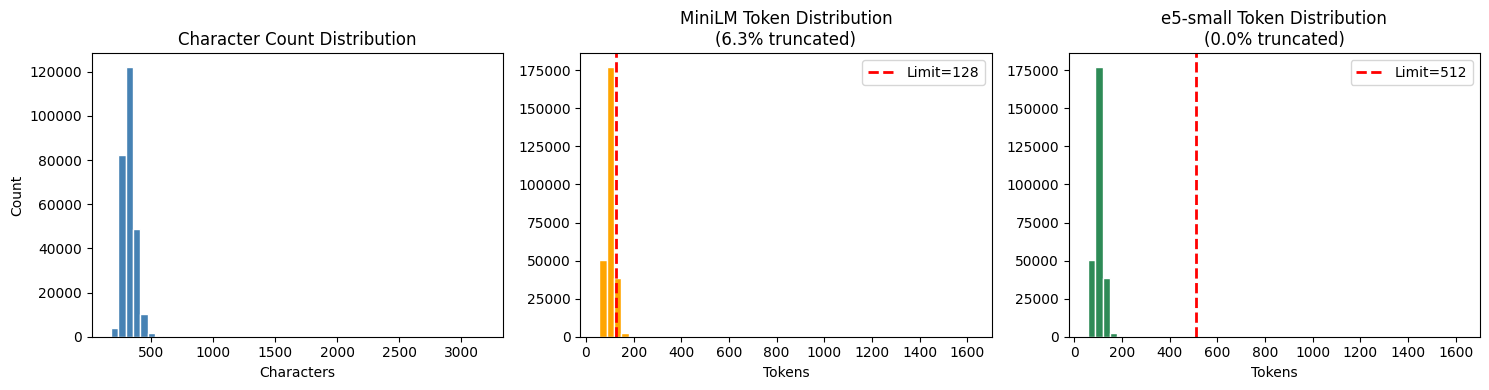

Saved token_analysis.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(char_lengths, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Character Count Distribution")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].hist(minilm_lengths, bins=50, color="orange", edgecolor="white")
axes[1].axvline(MINILM_LIMIT, color="red", linestyle="--", linewidth=2, label=f"Limit={MINILM_LIMIT}")
axes[1].legend()
axes[1].set_title(f"MiniLM Token Distribution\n({pct_over_minilm:.1f}% truncated)")
axes[1].set_xlabel("Tokens")

axes[2].hist(e5_lengths, bins=50, color="seagreen", edgecolor="white")
axes[2].axvline(E5_LIMIT, color="red", linestyle="--", linewidth=2, label=f"Limit={E5_LIMIT}")
axes[2].legend()
axes[2].set_title(f"e5-small Token Distribution\n({pct_over_e5:.1f}% truncated)")
axes[2].set_xlabel("Tokens")

plt.tight_layout()
plt.savefig("token_analysis.png", dpi=100)
plt.show()
print("Saved token_analysis.png")

## 7. Summary Table

In [9]:
stats = {
    "min":  lambda a: int(a.min()),
    "max":  lambda a: int(a.max()),
    "mean": lambda a: f"{a.mean():.1f}",
    "p50":  lambda a: int(np.percentile(a, 50)),
    "p90":  lambda a: int(np.percentile(a, 90)),
    "p95":  lambda a: int(np.percentile(a, 95)),
    "p99":  lambda a: int(np.percentile(a, 99)),
}

header = f"{'Metric':<8} {'Chars':>8} {'Words':>8} {'MiniLM':>8} {'e5-small':>10}"
print(header)
print("-" * len(header))
for name, fn in stats.items():
    print(f"{name:<8} {str(fn(char_lengths)):>8} {str(fn(word_lengths)):>8} "
          f"{str(fn(minilm_lengths)):>8} {str(fn(e5_lengths)):>10}")

print()
print(f"% truncated — MiniLM  (@{MINILM_LIMIT} tokens): {pct_over_minilm:.2f}%")
print(f"% truncated — e5-small (@{E5_LIMIT} tokens): {pct_over_e5:.2f}%")
print()
print("=> Kết luận: copy và gửi kết quả này vào chat để chọn model.")

Metric      Chars    Words   MiniLM   e5-small
----------------------------------------------
min           176       36       55         55
max          3184     1021     1623       1623
mean        323.4     68.1    101.1      101.1
p50           317       67       99         99
p90           389       83      123        123
p95           413       88      131        131
p99           466       99      150        150

% truncated — MiniLM  (@128 tokens): 6.33%
% truncated — e5-small (@512 tokens): 0.00%

=> Kết luận: copy và gửi kết quả này vào chat để chọn model.
